# Classification distance-based minimale

Version simplifiée avec résultats lisibles :
- Accuracy, F1, precision, recall, balanced accuracy
- Temps moyen de prédiction par image
- Précision/Recall/F1 par classe
- Matrice de confusion
- Validation croisée (moyenne et ecart-type)

In [1]:
%run setup.ipynb

import time
import cv2
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support,
    )
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

CLASS_IDS = sorted(np.unique(y))
CLASS_NAMES = [DIRECTION_NAMES[c] for c in CLASS_IDS]

print(f"Classes: {CLASS_NAMES}")
print(f"Total images: {len(y)}")

dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
DETECTION_METHOD : algo
East: 36 images


North: 59 images


South: 38 images


West: 34 images


Dataset chargé : 167 images, taille (128, 128)
Distribution   : {'East': 36, 'North': 59, 'South': 38, 'West': 34}
Classes: ['East', 'North', 'South', 'West']
Total images: 167


In [2]:
class FeatureExtractor:
    """Extract compact color/structure features for yellow-black buoys."""
    FIXED_SIZE = (128, 128)

    @staticmethod
    def extract(image):
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image = cv2.resize(image, FeatureExtractor.FIXED_SIZE)
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

        # Compact HSV histogram (48 dims)
        h_hist = cv2.normalize(cv2.calcHist([hsv], [0], None, [16], [0, 180]), None).flatten()
        s_hist = cv2.normalize(cv2.calcHist([hsv], [1], None, [16], [0, 256]), None).flatten()
        v_hist = cv2.normalize(cv2.calcHist([hsv], [2], None, [16], [0, 256]), None).flatten()

        # Yellow/black ratios
        rgb = image.astype(np.uint8)
        yellow_mask = (rgb[:, :, 0] > 150) & (rgb[:, :, 1] > 150) & (rgb[:, :, 2] < 120)
        black_mask = (rgb[:, :, 0] < 80) & (rgb[:, :, 1] < 80) & (rgb[:, :, 2] < 80)
        yellow_ratio = np.mean(yellow_mask)
        black_ratio = np.mean(black_mask)

        # Vertical thirds to capture stripe layout
        h = rgb.shape[0]
        t1, t2 = h // 3, 2 * h // 3
        thirds = [slice(0, t1), slice(t1, t2), slice(t2, h)]
        layout_features = []
        for sl in thirds:
            y_ratio = np.mean(yellow_mask[sl, :])
            b_ratio = np.mean(black_mask[sl, :])
            layout_features.extend([y_ratio, b_ratio])

        # Edge density
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        edge_density = np.mean(edges > 0)

        return np.concatenate([
            h_hist, s_hist, v_hist,
            np.array([yellow_ratio, black_ratio, edge_density], dtype=np.float32),
            np.array(layout_features, dtype=np.float32),
        ])

class DistanceBasedKNN:
    def __init__(self, k=3, metric='cosine'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        distances = cdist(X, self.X_train, metric=self.metric)
        preds = []
        confs = []
        for row in distances:
            idx = np.argsort(row)[:self.k]
            labels = self.y_train[idx]
            vals, counts = np.unique(labels, return_counts=True)
            pred = vals[np.argmax(counts)]
            conf = np.max(counts) / self.k
            preds.append(pred)
            confs.append(conf)
        return np.array(preds), np.array(confs)

def build_feature_matrix(X_crops, y_labels):
    """Extract features from crop images."""
    X_feat = []
    for crop in X_crops:
        X_feat.append(FeatureExtractor.extract(crop))
    return np.asarray(X_feat), np.asarray(y_labels)

def evaluate_pipeline(X_crops, y_labels, k=3, metric='cosine', test_size=0.4, random_state=42, cv_folds=5):
    X, y = build_feature_matrix(X_crops, y_labels)

    # On split aussi les crops bruts : ils servent a mesurer le temps de
    # traitement complet d'une nouvelle image test (extraction comprise).
    X_train, X_test, y_train, y_test, crops_train, crops_test = train_test_split(
        X, y, X_crops, test_size=test_size, stratify=y, random_state=random_state
    )

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = DistanceBasedKNN(k=k, metric=metric)
    clf.fit(X_train_s, y_train)

    y_pred, y_conf = clf.predict(X_test_s)

    # Temps de traitement d'une nouvelle image test : pipeline complet
    # crop -> extraction des descripteurs -> normalisation -> prediction.
    per_image_times = []
    for crop in crops_test:
        t0 = time.perf_counter()
        feat = FeatureExtractor.extract(crop)
        feat_s = scaler.transform(feat.reshape(1, -1))
        clf.predict(feat_s)
        per_image_times.append(time.perf_counter() - t0)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    p_cls, r_cls, f_cls, sup_cls = precision_recall_fscore_support(
        y_test, y_pred, labels=CLASS_IDS, zero_division=0
    )

    per_class_df = pd.DataFrame({
        'class': CLASS_NAMES,
        'precision': p_cls,
        'recall': r_cls,
        'f1': f_cls,
        'support': sup_cls,
    })

    cm = confusion_matrix(y_test, y_pred, labels=CLASS_IDS)
    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

    report = classification_report(
        y_test, y_pred, labels=CLASS_IDS, target_names=CLASS_NAMES, zero_division=0
    )

    # Cross-validation robustness
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    cv_acc = []
    cv_f1 = []
    for tr_idx, te_idx in cv.split(X, y):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        model = DistanceBasedKNN(k=k, metric=metric)
        model.fit(X_tr_s, y_tr)
        pred_cv, _ = model.predict(X_te_s)
        cv_acc.append(accuracy_score(y_te, pred_cv))
        cv_f1.append(f1_score(y_te, pred_cv, average='macro', zero_division=0))

    return {
        'n_total': len(y),
        'n_train': len(y_train),
        'n_test': len(y_test),
        'k': k,
        'metric': metric,
        'accuracy': float(acc),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted),
        'precision_macro': float(precision_macro),
        'recall_macro': float(recall_macro),
        'balanced_accuracy': float(bal_acc),
        'mean_confidence': float(np.mean(y_conf)),
        'time_ms_per_image': float(np.mean(per_image_times) * 1000.0),
        'per_class': per_class_df,
        'confusion_matrix': cm_df,
        'classification_report': report,
        'cv_acc_mean': float(np.mean(cv_acc)),
        'cv_acc_std': float(np.std(cv_acc)),
        'cv_f1_mean': float(np.mean(cv_f1)),
        'cv_f1_std': float(np.std(cv_f1)),
    }

RESULTATS (pipeline minimal)
Images totales: 167
Train/Test: 100/67
Modele: k-NN (k=3), metric=cosine

 Metriques globales 
Accuracy: 0.3433 (34.33%)
F1 macro: 0.3179
F1 weighted: 0.3266
Precision macro: 0.3199
Recall macro: 0.3426
Balanced accuracy: 0.3426
Confiance moyenne: 0.5721
Temps moyen prediction/image: 0.76 ms

 Precision/Recall/F1 par classe 
class  precision   recall       f1  support
 East   0.360000 0.642857 0.461538       14
North   0.428571 0.375000 0.400000       24
South   0.090909 0.066667 0.076923       15
 West   0.400000 0.285714 0.333333       14

 Matrice de confusion (lignes=vrai, colonnes=pred)
       East  North  South  West
East      9      1      3     1
North     7      9      4     4
South     3     10      1     1
West      6      1      3     4

 Validation croisee (5-fold)
Accuracy CV: 0.3164 +- 0.0822
F1 macro CV: 0.2915 +- 0.0921

 Classification report
              precision    recall  f1-score   support

        East       0.36      0.64      0.46

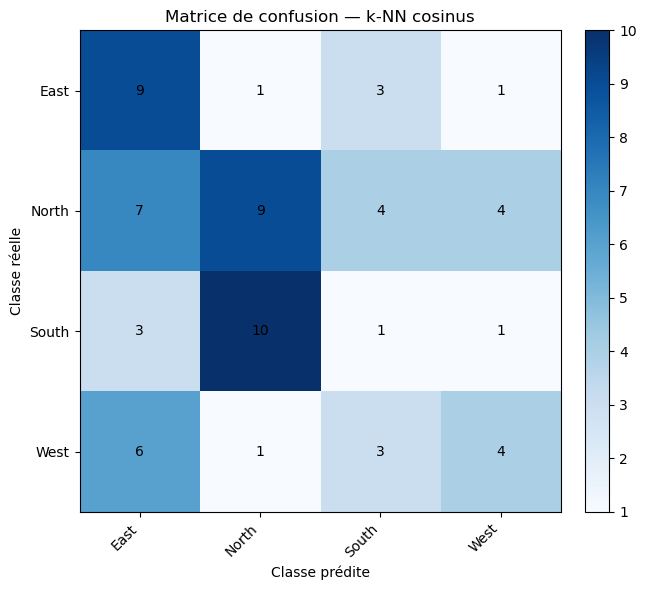

In [3]:
results = evaluate_pipeline(X, y, k=3, metric='cosine', test_size=0.4, random_state=42, cv_folds=5)

print('RESULTATS (pipeline minimal)')
print(f"Images totales: {results['n_total']}")
print(f"Train/Test: {results['n_train']}/{results['n_test']}")
print(f"Modele: k-NN (k={results['k']}), metric={results['metric']}")

print('\n Metriques globales ')
print(f"Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"F1 macro: {results['f1_macro']:.4f}")
print(f"F1 weighted: {results['f1_weighted']:.4f}")
print(f"Precision macro: {results['precision_macro']:.4f}")
print(f"Recall macro: {results['recall_macro']:.4f}")
print(f"Balanced accuracy: {results['balanced_accuracy']:.4f}")
print(f"Confiance moyenne: {results['mean_confidence']:.4f}")
print(f"Temps moyen prediction/image: {results['time_ms_per_image']:.2f} ms")

print('\n Precision/Recall/F1 par classe ')
print(results['per_class'].to_string(index=False))

print('\n Matrice de confusion (lignes=vrai, colonnes=pred)')
print(results['confusion_matrix'].to_string())

print('\n Validation croisee (5-fold)')
print(f"Accuracy CV: {results['cv_acc_mean']:.4f} +- {results['cv_acc_std']:.4f}")
print(f"F1 macro CV: {results['cv_f1_mean']:.4f} +- {results['cv_f1_std']:.4f}")

print('\n Classification report')
print(results['classification_report'])

import matplotlib.pyplot as plt

cm = results['confusion_matrix'].values
labels = results['confusion_matrix'].index.tolist()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Matrice de confusion — k-NN cosinus')
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()